# **Data Exploration:**

In [13]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings

In [15]:
warnings.filterwarnings(action= "ignore")

In [2]:
data= pd.read_csv("data.csv")
data.shape

(42468, 14)

### **1. Imbalanced Classes in Salary:** 

Objective: See if dataset is skewed toward one income group.
How: Count and compare entries of <=50K and >50K.

In [4]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [10]:
sjs= data['salary'].value_counts()   
sjs= sjs.reset_index()
sjs

,salary,count
0,<=50K,32020
1,>50K,10448


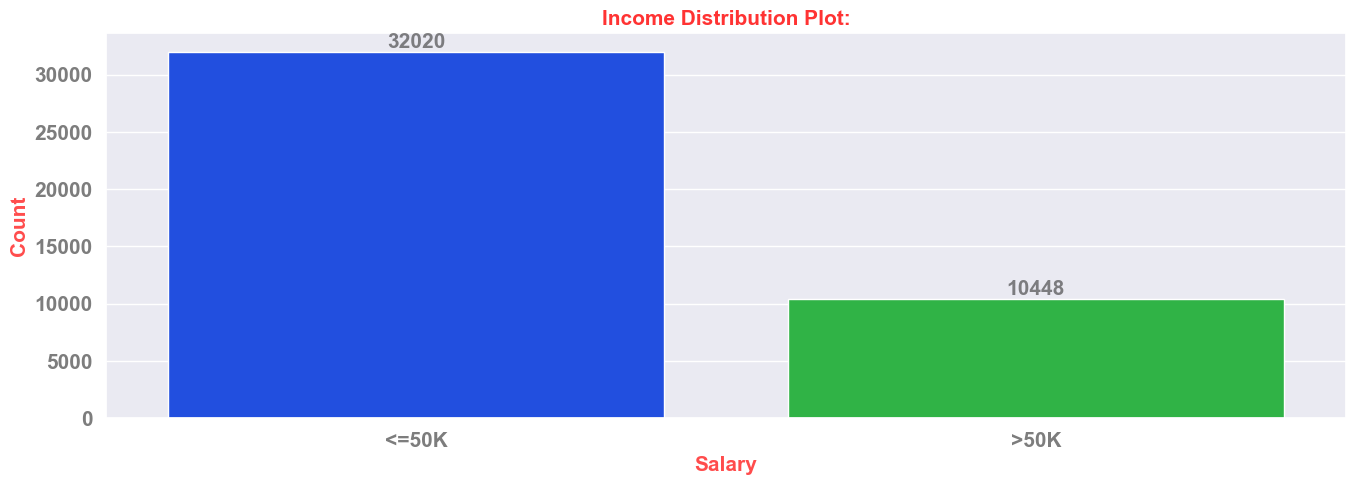

In [20]:
plt.figure(figsize= (16, 5))
sns.set_theme(style="darkgrid", context= "notebook")
sns.barplot(data= sjs, x= "salary", y= "count", palette= "bright6", )
plt.title("Income Distribution Plot:", color= "Red", fontsize= 15, fontweight= "bold",alpha= 0.8)
plt.xlabel("Salary", color= "Red", fontsize= 15, fontweight= "bold", alpha= 0.7)
plt.ylabel("Count", color= "Red", fontsize= 15, fontweight= "bold",alpha= 0.7)    
plt.xticks(fontsize= 15, fontweight= "bold", alpha= 0.6)
plt.yticks(fontsize= 15, fontweight= "bold", alpha= 0.6)
# add annotations:
for i in range(len(sjs)):
    plt.annotate(sjs['count'][i], xy= (sjs['salary'][i], sjs['count'][i]), ha= 'center', va= 'bottom', fontsize= 15, fontweight= "bold", alpha= 0.56)
plt.show()

---
---
---
---

### **2.  High Correlation Features:** 

Objective: Detect multicollinearity or strong relationships.
How: Use correlation matrix (especially for numeric columns).

In [26]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [27]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


In [28]:
data.select_dtypes(include= "number").head(3)

,age,education-num,capital-gain,capital-loss,hours-per-week
0,25,7,0,0,40
1,38,9,0,0,50
2,28,12,0,0,40


In [33]:
num_cols= data.select_dtypes(include= [np.int32, np.int64, np.float32, np.float64]).head(3)

In [35]:
per_corr= num_cols.corr(method= "pearson") # Pearson correlation
spe_cor= num_cols.corr(method= "spearman") # Spearman correlation

In [36]:
per_corr

,age,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,0.107023,NaN,NaN,0.975417
education-num,0.107023,1.000000,NaN,NaN,-0.114708
capital-gain,NaN,NaN,NaN,NaN,NaN
capital-loss,NaN,NaN,NaN,NaN,NaN
hours-per-week,0.975417,-0.114708,NaN,NaN,1.000000


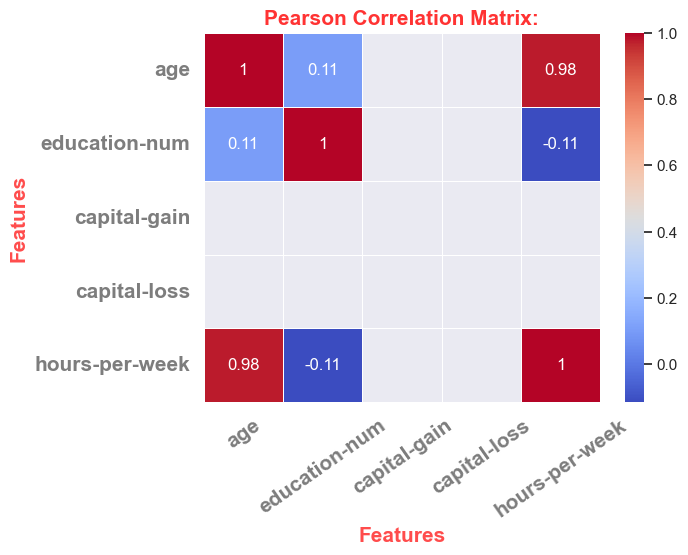

In [45]:
sns.set_theme(style= "dark", context= "notebook")
sns.heatmap(per_corr, annot= True, cmap= "coolwarm", linewidths= 0.5)
plt.title("Pearson Correlation Matrix:", color= "Red", fontsize= 15, fontweight= "bold", alpha= 0.8)
plt.xlabel("Features", color= "Red", fontsize= 15, fontweight= "bold", alpha= 0.7)
plt.ylabel("Features", color= "Red", fontsize= 15, fontweight= "bold", alpha= 0.7)
plt.xticks(fontsize= 15, fontweight= "bold", alpha= 0.6, rotation= 35)
plt.yticks(fontsize= 15, fontweight= "bold", alpha= 0.6)
plt.show()

In [46]:
spe_cor

,age,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,0.5,NaN,NaN,0.866025
education-num,0.500000,1.0,NaN,NaN,0.000000
capital-gain,NaN,NaN,NaN,NaN,NaN
capital-loss,NaN,NaN,NaN,NaN,NaN
hours-per-week,0.866025,0.0,NaN,NaN,1.000000


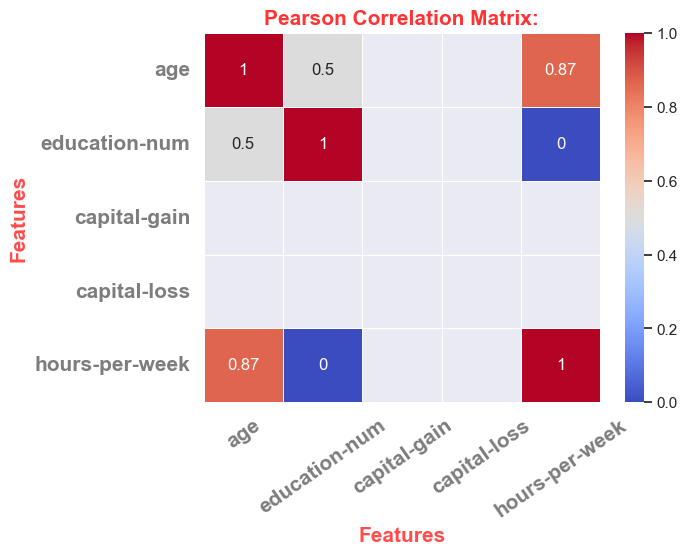

In [49]:
sns.set_theme(style= "dark", context= "notebook")
sns.heatmap(spe_cor, annot= True, cmap= "coolwarm", linewidths= 0.5)
plt.title("Pearson Correlation Matrix:", color= "Red", fontsize= 15, fontweight= "bold", alpha= 0.8)
plt.xlabel("Features", color= "Red", fontsize= 15, fontweight= "bold", alpha= 0.7)
plt.ylabel("Features", color= "Red", fontsize= 15, fontweight= "bold", alpha= 0.7)
plt.xticks(fontsize= 15, fontweight= "bold", alpha= 0.6, rotation= 35)
plt.yticks(fontsize= 15, fontweight= "bold", alpha= 0.6)
plt.show()

Very few predictor variables are numeric and out of them, only two relations are seem to be worth analyzing. `Hours per week` and `age` of the workers are highly correlated. This means, as the age increases, the average working hours of the person also increases in a monotonic fashion. `Education` and `age` also seem to have moderate correlation.